<p align="center">
<img src="Images/sorbonne_logo.png" alt="Logo" width="300"/>
</p>

# **Module 3 - AR Analysis**

* **Author**: Elia Landini
* **Student ID**: 12310239
* **Course**: EESM2-Financial Economics 
* **Supervisor**: Jean-Bernard Chatelain
* **Reference Repository**: https://github.com/EliaLand/Policy_Target_RegimeSwitchingPersistence

### **1) REQUIREMENTS SET-UP**

In [138]:
# Requirements.txt file installation
# !pip install -r requirements.txt

In [173]:
# Libraries import
import warnings
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
from matplotlib.patches import Circle
import matplotlib.patches as mpatches
%matplotlib inline
import seaborn as sns
import scipy.stats as stats
from scipy.stats import norm
from scipy.stats import levene
from scipy.stats import ks_2samp
from scipy.stats import kstest
from scipy.stats import pearsonr
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.filters.hp_filter import hpfilter
from statsmodels.tsa.ar_model import AutoReg
import statsmodels.api as sm
import sklearn.tree
import sklearn.metrics
import sklearn.metrics
import sklearn.model_selection
import sklearn.preprocessing 
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (roc_auc_score, roc_curve, confusion_matrix,
                             precision_score, recall_score, f1_score,
                             accuracy_score, precision_recall_curve, auc, 
                             RocCurveDisplay, ConfusionMatrixDisplay)
from sklearn.linear_model import (LinearRegression, LogisticRegression)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.utils.class_weight import compute_class_weight
import plotly.express as px
import openpyxl as pxl
from stargazer.stargazer import Stargazer
from IPython.core.display import HTML
from IPython.display import Image
import itertools
from arch.unitroot import PhillipsPerron

### **2) OVERTIME PLOTTING**

### **5) AR(2) PROCESS ESTIMATION**

In [140]:
# df import
jp_aggregated_df = pd.read_csv("Data/Aggregated/jp_aggregated_df.csv")
jp_trans_df = pd.read_csv("Data/Transformed/jp_trans_df.csv")
jp_core_trans_df = pd.read_csv("Data/Transformed/jp_core_trans_df.csv")
jp_core_hybrid_df = pd.read_csv("Data/Transformed/jp_core_hybrid_df.csv")

In [141]:
# General color settings (viridis palette)
core_trans_var_colors = {
    "LogDiff-HICP (SA)": "#1F9E89",  
    "AR(1)detrend-Call Money/Interbank Immediate (%)":       "#440154",  
    "AR(1)detrend-10-Year Gov Bond Yields (%)":       "#FDE725" 
}

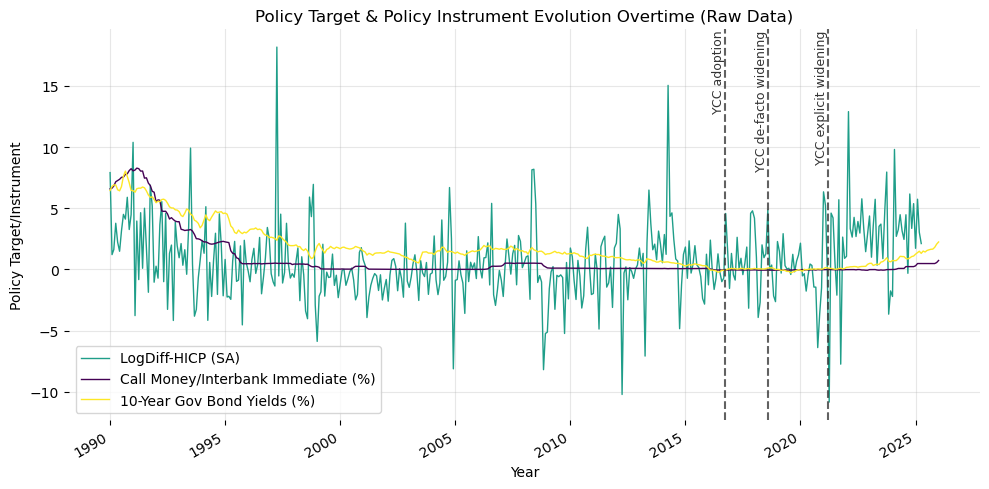

In [142]:
# Over time plotting (Raw Data): Policy Target (LogDiff-HICP (SA)) and Policy Instrument (Call Money/Interbank Immediate (%), 10-Year Gov Bond Yields (%)) 

fig, ax = plt.subplots(figsize=(10, 5))

# Index settings for the 2 datasets (jp_aggregated_df and jp_core_trans_df)
# (!!!) We also restrict the sample to observations later than 01/01/1990
jp_core_trans_df = jp_core_trans_df.reset_index()
jp_core_trans_df["Time"] = pd.to_datetime(jp_core_trans_df["Time"]) 
jp_core_trans_df = jp_core_trans_df.set_index("Time")
df1 = jp_core_trans_df.copy()
df1 = df1[df1.index >= "1990-01-01"]

jp_aggregated_df = jp_aggregated_df.reset_index()
jp_aggregated_df["Time"] = pd.to_datetime(jp_aggregated_df["Time"]) 
jp_aggregated_df = jp_aggregated_df.set_index("Time")
df2 = jp_aggregated_df.copy()
df2 = df2[df2.index >= "1990-01-01"]

# Plot set-up 
# (!!!) Separate plotting for raw and transformed variables
ax.plot(
    df1.index,
    df1["LogDiff-HICP (SA)"],
    label="LogDiff-HICP (SA)",
    linewidth=1,
    color = "#1F9E89"
    )

ax.plot(
    df2.index,
    df2["Call Money/Interbank Immediate (%)"],
    label= "Call Money/Interbank Immediate (%)",
    linewidth=1,
    color = "#440154"
    )
ax.plot(
    df2.index,
    df2["10-Year Gov Bond Yields (%)"],
    label="10-Year Gov Bond Yields (%)",
    linewidth=1,
    color = "#FDE725"
    )

# Reference vertical lines with respect to YCC adoption dates 
# YCC Adoption Line (2016-09-21)
ycc_date = pd.Timestamp("2016-09-21")
ax.axvline(
    ycc_date,
    color="#393939",
    lw=1.5,
    ls="--",
    alpha=0.8,
    zorder=10
)
ax.text(
    ycc_date,
    ax.get_ylim()[1],
    "YCC adoption",
    rotation=90,
    va="top",
    ha="right",
    fontsize=9,
    alpha=0.8
)
# YCC De-facto Widening Line (2016-09-21)
defacto_widen_date = pd.Timestamp("2018-07-31")
ax.axvline(
    defacto_widen_date,
    color="#393939",
    lw=1.5,
    ls="--",
    alpha=0.8,
    zorder=10
)
ax.text(
    defacto_widen_date,
    ax.get_ylim()[1],
    "YCC de-facto widening",
    rotation=90,
    va="top",
    ha="right",
    fontsize=9,
    alpha=0.8
)
# YCC Explicit Widening Line (2016-09-21)
explicit_widen_date = pd.Timestamp("2021-03-19")
ax.axvline(
    explicit_widen_date,
    color="#393939",
    lw=1.5,
    ls="--",
    alpha=0.8,
    zorder=10
)
ax.text(
    explicit_widen_date,
    ax.get_ylim()[1],
    "YCC explicit widening",
    rotation=90,
    va="top",
    ha="right",
    fontsize=9,
    alpha=0.8
)

# Time Fix
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# General settings 
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.set_title(f"Policy Target & Policy Instrument Evolution Overtime (Raw Data)")
ax.set_xlabel("Year")
ax.set_ylabel(f"Policy Target/Instrument")
ax.grid(True, alpha=0.3)
ax.legend()

# (!!!) autofmt_xdate() goes on fig not on ax
fig.autofmt_xdate()

plt.tight_layout()
plt.show()

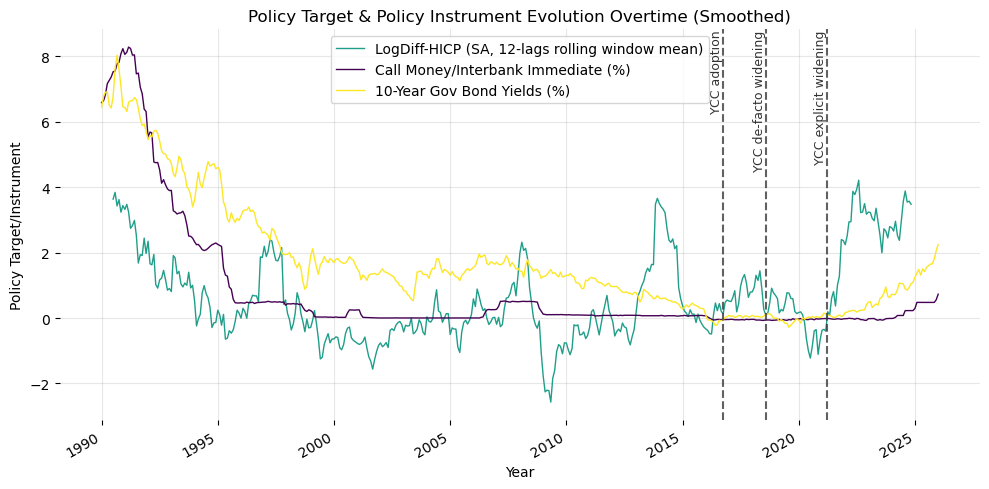

In [143]:
# Over time plotting (Raw Data): Policy Target (LogDiff-HICP (SA)) and Policy Instrument (Call Money/Interbank Immediate (%), 10-Year Gov Bond Yields (%)) 

fig, ax = plt.subplots(figsize=(10, 5))

# Index settings for the 2 datasets (jp_aggregated_df and jp_core_trans_df)
# (!!!) We also restrict the sample to observations later than 01/01/1990
jp_core_trans_df = jp_core_trans_df.reset_index()
jp_core_trans_df["Time"] = pd.to_datetime(jp_core_trans_df["Time"]) 
jp_core_trans_df = jp_core_trans_df.set_index("Time")
df1 = jp_core_trans_df.copy()
df1 = df1[df1.index >= "1990-01-01"]

jp_aggregated_df = jp_aggregated_df.reset_index()
jp_aggregated_df["Time"] = pd.to_datetime(jp_aggregated_df["Time"]) 
jp_aggregated_df = jp_aggregated_df.set_index("Time")
df2 = jp_aggregated_df.copy()
df2 = df2[df2.index >= "1990-01-01"]

# Smoothing Inflation (Rolling-Window Average)
df1["LogDiff-HICP (SA)-smooth"] = df1["LogDiff-HICP (SA)"].rolling(window=12, center=True).mean()

# Plot set-up 
# (!!!) Separate plotting for raw and transformed variables
ax.plot(
    df1.index,
    df1["LogDiff-HICP (SA)-smooth"],
    label="LogDiff-HICP (SA, 12-lags rolling window mean)",
    linewidth=1,
    color = "#1F9E89"
    )

ax.plot(
    df2.index,
    df2["Call Money/Interbank Immediate (%)"],
    label= "Call Money/Interbank Immediate (%)",
    linewidth=1,
    color = "#440154"
    )
ax.plot(
    df2.index,
    df2["10-Year Gov Bond Yields (%)"],
    label="10-Year Gov Bond Yields (%)",
    linewidth=1,
    color = "#FDE725"
    )

# Reference vertical lines with respect to YCC adoption dates 
# YCC Adoption Line (2016-09-21)
ycc_date = pd.Timestamp("2016-09-21")
ax.axvline(
    ycc_date,
    color="#393939",
    lw=1.5,
    ls="--",
    alpha=0.8,
    zorder=10
)
ax.text(
    ycc_date,
    ax.get_ylim()[1],
    "YCC adoption",
    rotation=90,
    va="top",
    ha="right",
    fontsize=9,
    alpha=0.8
)
# YCC De-facto Widening Line (2016-09-21)
defacto_widen_date = pd.Timestamp("2018-07-31")
ax.axvline(
    defacto_widen_date,
    color="#393939",
    lw=1.5,
    ls="--",
    alpha=0.8,
    zorder=10
)
ax.text(
    defacto_widen_date,
    ax.get_ylim()[1],
    "YCC de-facto widening",
    rotation=90,
    va="top",
    ha="right",
    fontsize=9,
    alpha=0.8
)
# YCC Explicit Widening Line (2016-09-21)
explicit_widen_date = pd.Timestamp("2021-03-19")
ax.axvline(
    explicit_widen_date,
    color="#393939",
    lw=1.5,
    ls="--",
    alpha=0.8,
    zorder=10
)
ax.text(
    explicit_widen_date,
    ax.get_ylim()[1],
    "YCC explicit widening",
    rotation=90,
    va="top",
    ha="right",
    fontsize=9,
    alpha=0.8
)

# Time Fix
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# General settings 
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.set_title(f"Policy Target & Policy Instrument Evolution Overtime (Smoothed)")
ax.set_xlabel("Year")
ax.set_ylabel(f"Policy Target/Instrument")
ax.grid(True, alpha=0.3)
ax.legend()

# (!!!) autofmt_xdate() goes on fig not on ax
fig.autofmt_xdate()

plt.tight_layout()
plt.show()

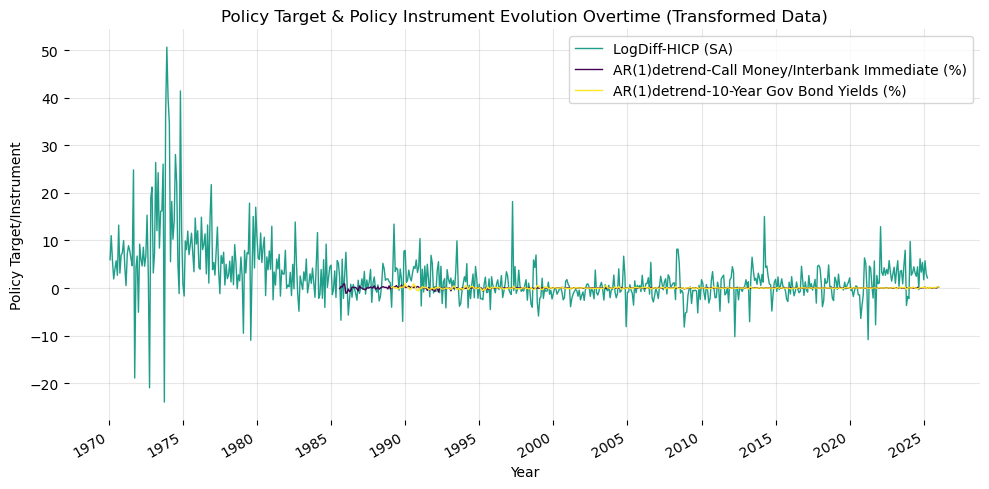

In [144]:
# Over time plotting (Transformed Data): Policy Target (LogDiff-HICP (SA)) and Policy Instrument (AR(1)detrend-Call Money/Interbank Immediate (%), AR(1)detrend-10-Year Gov Bond Yields (%)) 

df = jp_core_trans_df.copy()
df = df.reset_index()
df["Time"] = pd.to_datetime(df["Time"]) 
df = df.set_index("Time")
core_var = ["LogDiff-HICP (SA)", "AR(1)detrend-Call Money/Interbank Immediate (%)", "AR(1)detrend-10-Year Gov Bond Yields (%)"]

fig, ax = plt.subplots(figsize=(10, 5))

# Loop on variable (without country and time)
for var in core_var: 
# Plot set-up
# Loop on country
# (!!!) Check countries naming
    ax.plot(
        df.index,
        df[var],
        label=var,
        linewidth=1,
        color = core_trans_var_colors.get(var)
    )
# Time Fix
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# General settings 
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.set_title(f"Policy Target & Policy Instrument Evolution Overtime (Transformed Data)")
ax.set_xlabel("Year")
ax.set_ylabel(f"Policy Target/Instrument")
ax.grid(True, alpha=0.3)
ax.legend()

# (!!!) autofmt_xdate() goes on fig not on ax
fig.autofmt_xdate()

plt.tight_layout()
plt.show()

### **3) AR(1) PROCESS ESTIMATION**

In [145]:
# AR(1) Process Estimation - Inflation (LogDiff-HICP (SA))

# Inflation (pi)
pi = jp_core_trans_df["LogDiff-HICP (SA)"].dropna()
# AR(1) on inflation
# (!!!) We start from period 2 cuz otherwise we wont have observations for pi_t-1
# pi_t
pi_t  = pi.values[1:]
# pi_t-1
pi_tm1  = sm.add_constant(pi.values[:-1])
# Estimates
ar1_pi = sm.OLS(pi_t, pi_tm1).fit()
print(ar1_pi.summary())

# Residuals of inflation AR(1) (u_pi)
u_pi = ar1_pi.resid
# u_pi_t
u_pi_t = u_pi[1:]
# u_pi_t-1
u_pi_tm1 = sm.add_constant(u_pi[:-1])
# Residuals Estimates
ar1mar1_pi = sm.OLS(u_pi_t, u_pi_tm1).fit()
print(ar1mar1_pi.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.115
Model:                            OLS   Adj. R-squared:                  0.114
Method:                 Least Squares   F-statistic:                     85.69
Date:                Thu, 19 Mar 2026   Prob (F-statistic):           2.90e-19
Time:                        00:29:40   Log-Likelihood:                -2104.0
No. Observations:                 662   AIC:                             4212.
Df Residuals:                     660   BIC:                             4221.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.5614      0.242      6.447      0.0

In [146]:
# AR(1) Process Estimation - Policy Instrument (Call Money/Interbank Immediate (%), not transformed)

# Policy Instrument (i)
i = jp_aggregated_df["Call Money/Interbank Immediate (%)"].dropna()
# AR(1) on policy instrument
# (!!!) We start from period 2 cuz otherwise we wont have observations for i_t-1
# i_t
i_t = i.values[1:]
# i_t-1
i_tm1 = sm.add_constant(i.values[:-1])
# Estimates
ar1_i = sm.OLS(i_t, i_tm1).fit()
print(ar1_i.summary())

# Residuals of policy instrument AR(1) (u_i)
u_i = ar1_i.resid
# u_i_t
u_i_t = u_i[1:]
# u_i_t-1
u_i_tm1 = sm.add_constant(u_i[:-1])
# Residuals Estimates
ar1mar1_i = sm.OLS(u_i_t, u_i_tm1).fit()
print(ar1mar1_i.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.995
Model:                            OLS   Adj. R-squared:                  0.995
Method:                 Least Squares   F-statistic:                 9.252e+04
Date:                Thu, 19 Mar 2026   Prob (F-statistic):               0.00
Time:                        00:29:40   Log-Likelihood:                 211.00
No. Observations:                 486   AIC:                            -418.0
Df Residuals:                     484   BIC:                            -409.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0013      0.008     -0.161      0.8

In [147]:
# AR(1) Process Estimation - Output Gap (HPfilter-Real GDP (billions chained 2015 JPY))
# (!!!) The HP filter output gap is actually the more standard choice in DSGE and monetary policy models since it directly maps to the output gap term in the Taylor rule. 

# Output Gap (y)
y = jp_trans_df["HPfilter-Real GDP (billions chained 2015 JPY)"].dropna()
# AR(1) on output gap
# (!!!) We start from period 2 cuz otherwise we wont have observations for y_t-1
# y_t
y_t = y.values[1:]
# y_t-1
y_tm1 = sm.add_constant(y.values[:-1])
# Estimates
ar1_y = sm.OLS(y_t, y_tm1).fit()
print(ar1_y.summary())

# Residuals of output gap AR(1) (u_y)
u_y = ar1_y.resid
# u_y_t
u_y_t = u_y[1:]
# u_y_t-1
u_y_tm1 = sm.add_constant(u_y[:-1])
# Residuals Estimates
ar1mar1_y = sm.OLS(u_y_t, u_y_tm1).fit()
print(ar1mar1_y.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.532
Model:                            OLS   Adj. R-squared:                  0.530
Method:                 Least Squares   F-statistic:                     432.5
Date:                Thu, 19 Mar 2026   Prob (F-statistic):           9.87e-65
Time:                        00:29:40   Log-Likelihood:                 1390.4
No. Observations:                 383   AIC:                            -2777.
Df Residuals:                     381   BIC:                            -2769.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -2.739e-05      0.000     -0.083      0.9

### **4) RAW DATA AR(1) UNIT ROOT TESTING**

In [148]:
# Autocorrelation coefficients AR(1)
# Drop non-numeric columns and rows with missing values
df = jp_core_hybrid_df.copy()
jp_core_hybrid_numeric = df.drop(columns=["Country", "Time"]).dropna()

# AR(1) autocorrelation for each variable
ar1_results = {}
for col in jp_core_hybrid_numeric.columns:
    series = jp_core_hybrid_numeric[col]

# (!!!) lag-1 autocorrelation
    ar1 = series.autocorr(lag=1)
    ar1_results[col] = ar1

# Better to create a dataframe to display the results
jp_ar1_df = pd.DataFrame.from_dict(ar1_results, orient="index", columns=["AR(1)"])
jp_ar1_df

,AR(1)
LogDiff-HICP (SA),0.164478
Call Money/Interbank Immediate (%),0.998457
10-Year Gov Bond Yields (%),0.996330


In [149]:
# Unit-root Testing - Adfuller Test 
# Drop non-numeric columns and handle missing data
df = jp_core_hybrid_df.copy()
jp_core_hybrid_numeric = df.drop(columns=["Country", "Time"]).dropna()

# (!!!) We need to initialize the results as empty list before execuding the test
results = []

for col in jp_core_hybrid_numeric.columns:
    series = jp_core_hybrid_numeric[col]

# As before, we extract the AR(1) coefficients
    ar1 = series.autocorr(lag=1)

# Augmented Dickey-Fuller (ADF) unit root test 
    adf_result = adfuller(series, autolag="AIC")
    adf_stat = adf_result[0]
    p_value = adf_result[1]
    crit_values = adf_result[4]

    results.append({
        "Variable": col,
        "AR(1)": ar1,
        "ADF Statistic": adf_stat,
        "p-value": p_value,
        "Stationary - Absence of unit-root (HP1)": "Yes" if p_value < 0.05 else "No"
    })

jp_adf_df = pd.DataFrame(results)
jp_adf_df

,Variable,AR(1),ADF Statistic,p-value,Stationary - Absence of unit-root (HP1)
0,LogDiff-HICP (SA),0.164478,-4.495569,0.000200,Yes
1,Call Money/Interbank Immediate (%),0.998457,-4.747988,0.000068,Yes
2,10-Year Gov Bond Yields (%),0.996330,-1.783089,0.388889,No


In [150]:
# Unit-root Testing - Phillips-Perron Test 
# (!!!) We need to initialize the results as empty list before execuding the test
pp_results = []

for col in jp_core_hybrid_numeric.columns:
    series = jp_core_hybrid_numeric[col].dropna()
    
# Phillips–Perron test 
# (!!!) From arch instead of stats.models is much smoother
    test = PhillipsPerron(series)
    pp_results.append({
        "Variable": col,
        "PP Statistic": test.stat,
        "p-value": test.pvalue,
        "Stationary - Absence of unit-root (HP1)": "Yes" if test.pvalue < 0.05 else "No"
    })

jp_pp_df = pd.DataFrame(pp_results)
jp_pp_df

,Variable,PP Statistic,p-value,Stationary - Absence of unit-root (HP1)
0,LogDiff-HICP (SA),-20.024675,0.000000,Yes
1,Call Money/Interbank Immediate (%),-1.782157,0.389356,No
2,10-Year Gov Bond Yields (%),-1.623684,0.470798,No


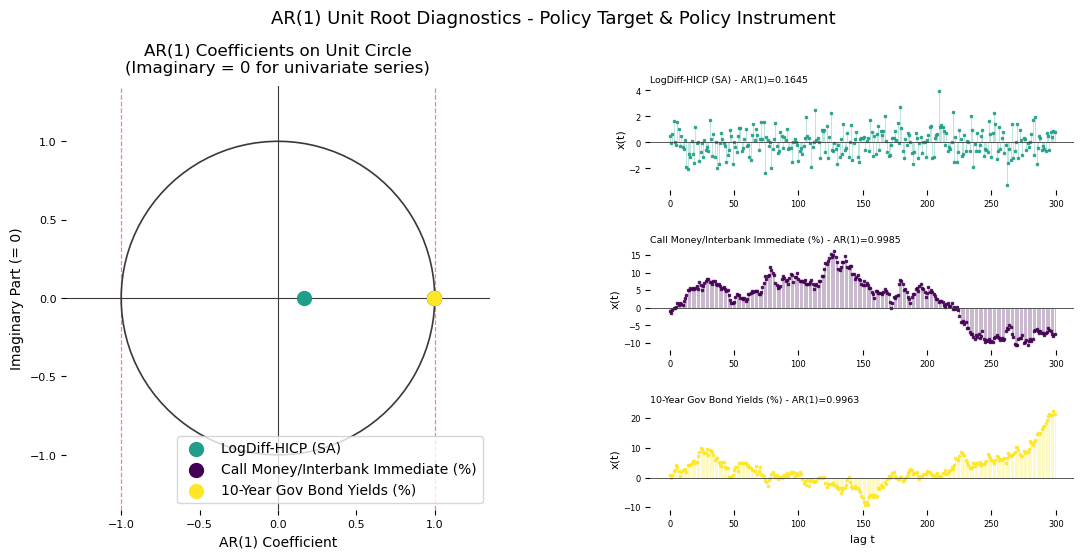

In [ ]:
# AR(1) Unit-Root Circle Plotting 

# General settings & Parameters
# We extract values and parameters from the ADF unit root tests
core_variables = jp_adf_df["Variable"].tolist()
ar1_values = jp_adf_df["AR(1)"].values         
stationary  = jp_adf_df["Stationary - Absence of unit-root (HP1)"].tolist()
# Angle of the circle
theta = np.linspace(0, 2 * np.pi, 100)
# Color Palette 
palette = ["#1F9E89", "#440154", "#FDE725"]
colors  = [palette[i % len(palette)] for i in range(len(core_variables))]
# Figure settings
fig = plt.figure(figsize=(13, 5.5), facecolor="#ffffff")
gs  = gridspec.GridSpec(1, 2, width_ratios=[1, 1], wspace=0.38)





# Unit Root Circle
ax1 = fig.add_subplot(gs[0])
ax1.set_facecolor("#ffffff")

# Plot components:
# 1) Unit circle
ax1.plot(np.cos(theta), np.sin(theta), color="#393939", lw=1.2, zorder=1)
# 2) Vertical and horizontal axes (0,0)
ax1.axhline(0, color="#393939", lw=0.8, zorder=0)
ax1.axvline(0, color="#393939", lw=0.8, zorder=0)
# 3) +1, -1 Vertical Stationarity limits (-1, +1)
ax1.axvline(1.0,  color="#ff0000", lw=0.9, linestyle="--", alpha=0.5, zorder=0)
ax1.axvline(-1.0, color="#ff0000", lw=0.9, linestyle="--", alpha=0.5, zorder=0)

# Variables lambda on the circle 
# AR(1) coefficients live on the real axis (imaginary = 0)
for i, (ar1, var, stat, col) in enumerate(zip(ar1_values, core_variables, stationary, colors)):
# (!!!) To plot the lambda point we can use the scatter function
    ax1.scatter(ar1, 0, color=col, s=100, zorder=4, linewidths=1.0, label=var)

# Subplot settings
# (!!!) Set .set_aspect to "equal" and not "auto" or it deforms the unit root circle into an ellipse
ax1.set_xlim(-1.35, 1.35)
ax1.set_ylim(-1.35, 1.35)
ax1.set_aspect("equal")
ax1.set_title("AR(1) Coefficients on Unit Circle\n(Imaginary = 0 for univariate series)", pad=10)
ax1.set_xlabel("AR(1) Coefficient")
ax1.set_ylabel("Imaginary Part (= 0)")
ax1.tick_params(labelsize=8)
for spine in ax1.spines.values():
    spine.set_visible(False)
ax1.legend(loc="lower right")







# Simulated AR(1) processes 
# Grid settings
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1], wspace=0.38) 
gs_right = gridspec.GridSpecFromSubplotSpec(
    len(core_variables), 1,
    subplot_spec=gs[1],
    hspace=0.55
)

# Simulation Parameters
# Random seed
np.random.seed(42)
# Number of steps to simulate
N = 300

# Simulation Plotting
for i, (var, ar1, col, stat) in enumerate(zip(core_variables, ar1_values, colors, stationary)):
    ax = fig.add_subplot(gs_right[i])
    ax.set_facecolor("#ffffff")
# Simulation of the AR(1) process: x_t = ar1 * x_{t-1} + u_t
    eps = np.random.normal(0, 1, N)
    y = np.zeros(N)
    y[0] = eps[0]
    for t in range(1, N):
        y[t] = ar1 * y[t - 1] + eps[t]
# Stem-style plot (squared dots with hortogonal lines to the 0 axis)
    markerline, stemlines, baseline = ax.stem(
        np.arange(N), y,
        linefmt=col,
        markerfmt=f"s",           
        basefmt=" "               
    )
    plt.setp(stemlines, lw=0.4, alpha=0.5, color=col)
    plt.setp(markerline, markersize=2.0, color=col, alpha=0.85)
# Horizontal zero line
    ax.axhline(0, color="#393939", lw=0.6)
# Cosmetics
    ax.set_title(
        f"{var} - AR(1)={ar1:.4f}",
        fontsize=6.8, loc="left", pad=3
    )
# ylabel: x(t)
    ax.set_ylabel("x(t)", fontsize=8, labelpad=2)
    ax.tick_params(labelsize=6)
    for spine in ax.spines.values():
        spine.set_visible(False)
# xlabel (we only plot the x label on the last bottom subplot)
    if i == len(core_variables) - 1:
        ax.set_xlabel("lag t", fontsize=8)






plt.suptitle("AR(1) Unit Root Diagnostics - Policy Target & Policy Instrument", fontsize=13, y=1.02)
plt.show()

In [152]:
# Autocorrelation coefficients AR(1)
# Drop non-numeric columns and rows with missing values
df = jp_trans_df.copy()
jp_transformed_numeric = df.drop(columns=["Country", "Time"]).dropna()

# AR(1) autocorrelation for each variable
ar1_results = {}
for col in jp_transformed_numeric.columns:
    series = jp_transformed_numeric[col]

# (!!!) lag-1 autocorrelation
    ar1 = series.autocorr(lag=1)
    ar1_results[col] = ar1

# Better to create a dataframe to display the results
jp_ar1_df = pd.DataFrame.from_dict(ar1_results, orient="index", columns=["AR(1)"])
jp_ar1_df

,AR(1)
LogDiff-Monetary Aggregates - M1 (JPY),0.484798
LogDiff-Monetary Aggregates - M2 (JPY),0.199956
LogDiff-Monetary Aggregates - M3 (JPY),0.321124
LogDiff-Total Treasury Reserves (- Gold),0.004811
LogDiff-USD-JPY reer CPI-based (Index 2015=100),0.373360
LogDiff-JPY-USD Spot Exchange Rate,0.343790
LogDiff-HICP (SA),0.291981
LogDiff-1615.T-Price,0.057838
LogDiff-BoJ’s Total Assets (100 Million Yen),-0.232157
AR(1)detrend-Total Credit - General Government (%GDP),-0.162293


### **5) AR(2) PROCESS ESTIMATION**

In [153]:
# AR(2) Process Estimation - Inflation (LogDiff-HICP (SA))

# Inflation (pi)
pi = jp_core_trans_df["LogDiff-HICP (SA)"].dropna()
# AR(1) on inflation
# (!!!) We start from period 3 cuz otherwise we wont have observations for pi_t, pi_t-2
# (!!!) Instead of pi_t+1 like the problem set says, we use pi_t, i like it better for comparability 
# pi_t, pi_t-1, pi_t-2
pi_t   = pi.values[2:]          
pi_tm1 = pi.values[1:-1]       
pi_tm2 = pi.values[:-2] 
# Constant
X_ar2 = sm.add_constant(np.column_stack([pi_tm1, pi_tm2]))
# Estimates
ar2_pi = sm.OLS(pi_t, X_ar2).fit()
print(ar2_pi.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.145
Model:                            OLS   Adj. R-squared:                  0.143
Method:                 Least Squares   F-statistic:                     55.95
Date:                Thu, 19 Mar 2026   Prob (F-statistic):           3.61e-23
Time:                        00:29:42   Log-Likelihood:                -2088.8
No. Observations:                 661   AIC:                             4184.
Df Residuals:                     658   BIC:                             4197.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.2603      0.246      5.134      0.0

In [154]:
# AR(2) Process Estimation - Policy Instrument (Call Money/Interbank Immediate (%), not transformed)

# Policy Instrument (i)
i = jp_aggregated_df["Call Money/Interbank Immediate (%)"].dropna()
# AR(1) on policy instrument
# (!!!) We start from period 3 cuz otherwise we wont have observations for i_t-1 and i_t-1
# (!!!) Instead of i_t+1 like the problem set says, we use i_t, i like it better for comparability 
# i_t, i_t-1, i_t-2
i_t = i.values[2:]          
i_tm1 = i.values[1:-1]       
i_tm2 = i.values[:-2] 
# Constant
X_ar2 = sm.add_constant(np.column_stack([i_tm1, i_tm2]))
# Estimates
ar2_i = sm.OLS(i_t, X_ar2).fit()
print(ar2_i.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.995
Model:                            OLS   Adj. R-squared:                  0.995
Method:                 Least Squares   F-statistic:                 4.845e+04
Date:                Thu, 19 Mar 2026   Prob (F-statistic):               0.00
Time:                        00:29:43   Log-Likelihood:                 224.90
No. Observations:                 485   AIC:                            -443.8
Df Residuals:                     482   BIC:                            -431.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0006      0.008      0.072      0.9

In [155]:
# AR(2) Process Estimation - Output Gap (HPfilter-Real GDP (billions chained 2015 JPY))
# (!!!) The HP filter output gap is actually the more standard choice in DSGE and monetary policy models since it directly maps to the output gap term in the Taylor rule. 

# Output Gap (y)
y = jp_trans_df["HPfilter-Real GDP (billions chained 2015 JPY)"].dropna()
# AR(1) on output gap
# (!!!) We start from period 2 cuz otherwise we wont have observations for y_t-1, y-t-2
# (!!!) Instead of y_t+1 like the problem set says, we use y_t, i like it better for comparability 
# y_t, y_t-1, y_t-2
y_t = y.values[2:]          
y_tm1 = y.values[1:-1]       
y_tm2 = y.values[:-2] 
# Constant
X_ar2 = sm.add_constant(np.column_stack([y_tm1, y_tm2]))
# Estimates
ar2_y = sm.OLS(y_t, X_ar2).fit()
print(ar2_y.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.533
Model:                            OLS   Adj. R-squared:                  0.531
Method:                 Least Squares   F-statistic:                     216.5
Date:                Thu, 19 Mar 2026   Prob (F-statistic):           1.94e-63
Time:                        00:29:43   Log-Likelihood:                 1387.3
No. Observations:                 382   AIC:                            -2769.
Df Residuals:                     379   BIC:                            -2757.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -2.892e-05      0.000     -0.088      0.9

### **6) AR(2) UNIT ROOT TESTING**

In [156]:
# AR(2) Unit Root Testing - Inflation

# Parameters Definitions
# (!!!) We have the 3 parameters of delta, a,b,c bringing delta to zero
# (!!!) a=const, b=phi_t-1 (pi_t-1) and c=phi_t-2 (pi_t-2)
# Extraction from the previous estimates:
# Constant (a):
const = ar2_pi.params[0]
# phi_t-1 (b):
pi_phi_tm1  = ar2_pi.params[1]
# phi_t-2 (c):
pi_phi_tm2 = ar2_pi.params[2]  

# Characteristic polynomial: 
# X² - (λ_π + ρ_π)X - λ_π ρ_π = 0
# (!!!) Command to get the roots from the coefficients: np.roots(coeffs)
# coeff = [a, b, c]
coeffs = [1, -(pi_phi_tm1 + pi_phi_tm2), -(pi_phi_tm1 * pi_phi_tm2)]
pi_ar2_roots  = np.roots(coeffs)

# Results
# (!!!) Complex coniugate happens when delta<0, so only defined in i
rows = []
for i, r in enumerate(pi_ar2_roots):
    rows.append({
        "Lagged Variable" : f"pi_{i+1}",
        "Root" : f"{r}",
        "Modulus |X|": round(abs(r), 6),
        "Inside Unit Disk (|X|<1)" : "Yes" if abs(r) < 1 else "No",
        "Real Root or Complex Conjugate (Δ<0)" : "Real Root" if np.isreal(r) else "Complex conjugate"
    })

pi_AR2_roots = pd.DataFrame(rows).set_index("Lagged Variable")
pi_AR2_roots

,Root,Modulus |X|,Inside Unit Disk (|X|<1),Real Root or Complex Conjugate (Δ<0)
Lagged Variable,,,,
pi_1,0.5535652303577507,0.553565,Yes,Real Root
pi_2,-0.09249556789624543,0.092496,Yes,Real Root


In [157]:
# AR(2) Unit Root Testing - Policy Instrument

# Parameters Definitions
# (!!!) We have the 3 parameters of delta, a,b,c bringing delta to zero
# (!!!) a=const, b=phi_t-1 (i_t-1) and c=phi_t-2 (i_t-2)
# Extraction from the previous estimates:
# Constant (a):
const = ar2_i.params[0]
# phi_t-1 (b):
i_phi_tm1  = ar2_i.params[1]
# phi_t-2 (c):
i_phi_tm2 = ar2_i.params[2]  

# Characteristic polynomial: 
# X² - (λ_i + ρ_i)X - λ_i ρ_i = 0
# (!!!) Command to get the roots from the coefficients: np.roots(coeffs)
# coeff = [a, b, c]
coeffs = [1, -(i_phi_tm1 + i_phi_tm2), -(i_phi_tm1 * i_phi_tm2)]
i_ar2_roots  = np.roots(coeffs)

# Results
rows = []
for i, r in enumerate(i_ar2_roots):
    rows.append({
        "Lagged Variable" : f"i_{i+1}",
        "Root" : f"{r}",
        "Modulus |X|": round(abs(r), 6),
        "Inside Unit Disk (|X|<1)" : "Yes" if abs(r) < 1 else "No",
        "Real Root or Complex Conjugate (Δ<0)" : "Real Root" if np.isreal(r) else "Complex conjugate"
    })

i_AR2_roots = pd.DataFrame(rows).set_index("Lagged Variable")
i_AR2_roots

,Root,Modulus |X|,Inside Unit Disk (|X|<1),Real Root or Complex Conjugate (Δ<0)
Lagged Variable,,,,
i_1,(0.4963428697748463+0.22312277411540954j),0.544187,Yes,Complex conjugate
i_2,(0.4963428697748463-0.22312277411540954j),0.544187,Yes,Complex conjugate


<>:116: SyntaxWarning: invalid escape sequence '\p'
<>:116: SyntaxWarning: invalid escape sequence '\p'
<>:116: SyntaxWarning: invalid escape sequence '\p'
<>:116: SyntaxWarning: invalid escape sequence '\p'
C:\Users\eland\AppData\Local\Temp\ipykernel_16808\364624349.py:116: SyntaxWarning: invalid escape sequence '\p'
  f"{var} — $\phi_1$={phi1:.4f}, $\phi_2$={phi2:.4f}, $|X|$={mod:.4f}",
C:\Users\eland\AppData\Local\Temp\ipykernel_16808\364624349.py:116: SyntaxWarning: invalid escape sequence '\p'
  f"{var} — $\phi_1$={phi1:.4f}, $\phi_2$={phi2:.4f}, $|X|$={mod:.4f}",


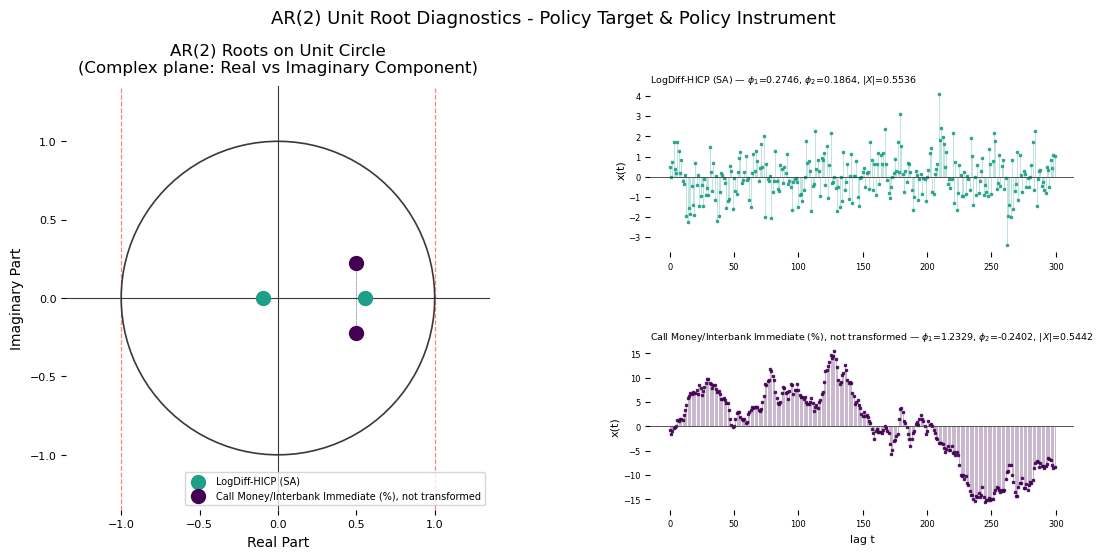

In [ ]:
# AR(2) Unit-Root Circle Plotting
# (!!!) Pretty much the same thing as for AR(1) but i need to specify the variables differently because now they are saved in two different dfs while before they were incorporated in the same adf/pp df

# General settings & Parameters
# AR(2) coefficients from previous OLS estimates
# Variable labels, root sets and AR(2) coefficient pairs for simulation
core_variables = ["LogDiff-HICP (SA)", "Call Money/Interbank Immediate (%), not transformed"]
all_roots      = [pi_ar2_roots, i_ar2_roots]
ar2_params     = [(pi_phi_tm1, pi_phi_tm2), (i_phi_tm1, i_phi_tm2)]
# Angle of the circle
theta = np.linspace(0, 2 * np.pi, 100)
# Color Palette
palette = ["#1F9E89", "#440154", "#FDE725"]
colors  = [palette[i % len(palette)] for i in range(len(core_variables))]
# Figure settings
fig = plt.figure(figsize=(13, 5.5), facecolor="#ffffff")
gs  = gridspec.GridSpec(1, 2, width_ratios=[1, 1], wspace=0.38)




# Unit Root Circle
ax1 = fig.add_subplot(gs[0])
ax1.set_facecolor("#ffffff")

# Plot components:
# 1) Unit circle
ax1.plot(np.cos(theta), np.sin(theta), color="#393939", lw=1.2, zorder=1)
# 2) Vertical and horizontal axes (0,0)
ax1.axhline(0, color="#393939", lw=0.8, zorder=0)
ax1.axvline(0, color="#393939", lw=0.8, zorder=0)
# 3) +1, -1 Vertical Stationarity limits (-1, +1)
ax1.axvline( 1.0, color="#ff0000", lw=0.9, linestyle="--", alpha=0.5, zorder=0)
ax1.axvline(-1.0, color="#ff0000", lw=0.9, linestyle="--", alpha=0.5, zorder=0)

# Variables roots on the circle
# AR(2) roots can be complex: plot real part on x-axis, imaginary part on y-axis
for i, (roots, var, col) in enumerate(zip(all_roots, core_variables, colors)):
    for j, r in enumerate(roots):
# (!!!) To plot the root point we use the scatter function 
# (!!!) This is the main difference from AR(1), we decompose the root in its real and imaginary part, that will be plotted on the y axis 
        ax1.scatter(
            r.real, r.imag,
            color=col, s=100, zorder=4, linewidths=1.0,
# (!!!) "_nolegend_" is fire, it removes the legend without using an if clause 
            label=f"{var}" if j == 0 else "_nolegend_"
        )
# Exception for conjugates pairs
# (!!!) We connect the two opposite solutions with a dot line
        if not np.isreal(r):
            ax1.plot([r.real, r.real], [r.imag, -r.imag],
                     color=col, lw=0.6, linestyle=":", alpha=0.5, zorder=2)

# Subplot settings
# (!!!) Set .set_aspect to "equal" and not "auto" or it deforms the unit root circle into an ellipse
ax1.set_xlim(-1.35, 1.35)
ax1.set_ylim(-1.35, 1.35)
ax1.set_aspect("equal")
ax1.set_title("AR(2) Roots on Unit Circle\n(Complex plane: Real vs Imaginary Component)", pad=10)
ax1.set_xlabel("Real Part")
ax1.set_ylabel("Imaginary Part")
ax1.tick_params(labelsize=8)
for spine in ax1.spines.values():
    spine.set_visible(False)
ax1.legend(loc="lower right", fontsize=7)








# Simulated AR(2) processes
# (!!!) Same as before but we add the second coefficient for x_t-2

# Grid settings
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1], wspace=0.38)
gs_right = gridspec.GridSpecFromSubplotSpec(
    len(core_variables), 1,
    subplot_spec=gs[1],
    hspace=0.55
)
# Simulation Parameters
# Random seed
np.random.seed(42)
# Number of steps to simulate
N = 300

# Simulation Plotting
for i, (var, (phi1, phi2), col, roots) in enumerate(zip(core_variables, ar2_params, colors, all_roots)):
    ax = fig.add_subplot(gs_right[i])
    ax.set_facecolor("#ffffff")
# Simulation of the AR(2) process: x_t = phi1 * x_{t-1} + phi2 * x_{t-2} + u_t
    eps = np.random.normal(0, 1, N)
    y   = np.zeros(N)
    y[0] = eps[0]
    y[1] = phi1 * y[0] + eps[1]
    for t in range(2, N):
        y[t] = phi1 * y[t - 1] + phi2 * y[t - 2] + eps[t]
# Stem-style plot (squared dots with orthogonal lines to the 0 axis)
    markerline, stemlines, baseline = ax.stem(
        np.arange(N), y,
        linefmt=col,
        markerfmt="s",
        basefmt=" "
    )
    plt.setp(stemlines,  lw=0.4, alpha=0.5, color=col)
    plt.setp(markerline, markersize=2.0, color=col, alpha=0.85)
# Horizontal zero line
    ax.axhline(0, color="#393939", lw=0.6)
# Cosmetics
# Modulus of the first root (both share same modulus for conjugate pairs)
    mod = abs(roots[0])
    ax.set_title(
        f"{var} — $\phi_1$={phi1:.4f}, $\phi_2$={phi2:.4f}, $|X|$={mod:.4f}",
        fontsize=6.8, loc="left", pad=3
    )
# ylabel: x(t)
    ax.set_ylabel("x(t)", fontsize=8, labelpad=2)
    ax.tick_params(labelsize=6)
    for spine in ax.spines.values():
        spine.set_visible(False)
# xlabel (we only plot the x label on the last bottom subplot)
    if i == len(core_variables) - 1:
        ax.set_xlabel("lag t", fontsize=8)





plt.suptitle("AR(2) Unit Root Diagnostics - Policy Target & Policy Instrument", fontsize=13, y=1.02)
plt.show()

<>:37: SyntaxWarning: invalid escape sequence '\p'
<>:38: SyntaxWarning: invalid escape sequence '\p'
<>:39: SyntaxWarning: invalid escape sequence '\p'
<>:66: SyntaxWarning: invalid escape sequence '\p'
<>:37: SyntaxWarning: invalid escape sequence '\p'
<>:38: SyntaxWarning: invalid escape sequence '\p'
<>:39: SyntaxWarning: invalid escape sequence '\p'
<>:66: SyntaxWarning: invalid escape sequence '\p'
C:\Users\eland\AppData\Local\Temp\ipykernel_16808\1364350936.py:37: SyntaxWarning: invalid escape sequence '\p'
  ax.text( 1.2,  0.05, f"$\phi_1$*$\phi_2$ = ($\phi_1$ + $\phi_2$) - 1", fontsize=8, color="#1F9E89")
C:\Users\eland\AppData\Local\Temp\ipykernel_16808\1364350936.py:38: SyntaxWarning: invalid escape sequence '\p'
  ax.text(-2.1,  0.05, f"$\phi_1$*$\phi_2$ = -($\phi_1$ + $\phi_2$) - 1", fontsize=8, color="#1F9E89")
C:\Users\eland\AppData\Local\Temp\ipykernel_16808\1364350936.py:39: SyntaxWarning: invalid escape sequence '\p'
  ax.text(0,  1.04, f"$\phi_1$*$\phi_2$ = 1", fonts

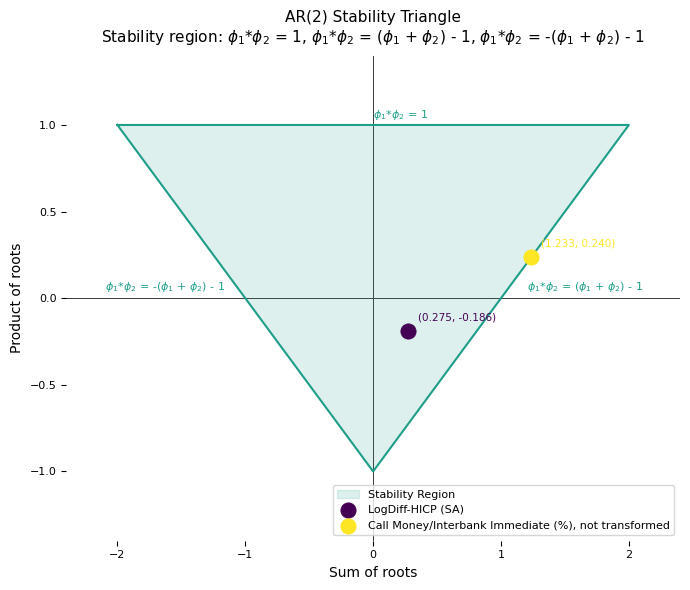

In [195]:
# AR(2) Unit Root Stability Triangle Plotting 
# (!!!) Stability conditions: 
# 1) phi_t-1*phi_t-2 < 1
# 2) phi_t-1*phi_t-2 > (phi_t-1 + phi_t-2)  - 1       
# 3) phi_t-1*phi_t-2 > -(phi_t-1 + phi_t-2) - 1     
# (!!!) So the vertices are in: (-2, 1), (2, 1), (0, -1)

# Variable Definition (phis for t-1 and t-2)
# Inflation
# Sum of phis (phi_t-1)
sum_pi = pi_phi_tm1  
# Product of phis (-phi_t-2)         
product_pi = -pi_phi_tm2          
# Policy Instrument
# Same thing
sum_i  = i_phi_tm1          
product_i  = -i_phi_tm2          

# Stability Triangle Plotting
# General Settings
fig, ax = plt.subplots(figsize=(7, 6), facecolor="#ffffff")
ax.set_facecolor("#ffffff")

# Vertoces and stability region
# (!!!) the vertices are in: (-2, 1), (2, 1), (0, -1)
# Limit Sum 
# (!!!) Obviously each phi cannot exceed 1 in module or it would lead to increasing x, so the max must be either +2 or -2
triangle_sum = np.array([-2,  2,  0, -2])
# Limit Product
# (!!!) As we have just set the limit of the sum of coefficients to |2|, the maximum product we can get with two terms is |1| when both coefficients are on the hedge
triangle_product = np.array([ 1,  1, -1,  1])
ax.fill(triangle_sum, triangle_product, color="#1F9E89", alpha=0.15, label="Stability Region")
ax.plot(triangle_sum, triangle_product, color="#1F9E89", lw=1.5)

# Boundary labels
# (!!!) Remember to not rotate the ticks for left and right boundaries (too complicated) and use only the horizzontal axis to locate the labels
ax.text( 1.2,  0.05, f"$\phi_1$*$\phi_2$ = ($\phi_1$ + $\phi_2$) - 1", fontsize=8, color="#1F9E89")
ax.text(-2.1,  0.05, f"$\phi_1$*$\phi_2$ = -($\phi_1$ + $\phi_2$) - 1", fontsize=8, color="#1F9E89")
ax.text(0,  1.04, f"$\phi_1$*$\phi_2$ = 1", fontsize=8, color="#1F9E89")

# Reference axes
ax.axhline(0, color="#393939", lw=0.7, zorder=0)
ax.axvline(0, color="#393939", lw=0.7, zorder=0)

# Roots points
# (!!!) Exactely as for the circle
core_variables = ["LogDiff-HICP (SA)", "Call Money/Interbank Immediate (%), not transformed"]
sum_operator = [sum_pi, sum_i]
product_operator =[product_pi, product_i]
palette = ["#440154", "#FDE725"]
for S, P, var, col in zip(sum_operator, product_operator, core_variables, palette):
    ax.scatter(S, P, color=col, s=120, zorder=5, edgecolors= col, lw=0.6, label=var)
# Point Label
    ax.annotate(
        f"({S:.3f}, {P:.3f})",
        xy=(S, P), xytext=(S + 0.08, P + 0.06),
        fontsize=7.5, color=col
    )

# Cosmetics
ax.set_xlim(-2.4, 2.4)
ax.set_ylim(-1.4, 1.4)
ax.set_xlabel(f"Sum of roots",     fontsize=10)
ax.set_ylabel(f"Product of roots", fontsize=10)
ax.set_title("AR(2) Stability Triangle\n"
             f"Stability region: $\phi_1$*$\phi_2$ = 1, $\phi_1$*$\phi_2$ = ($\phi_1$ + $\phi_2$) - 1, $\phi_1$*$\phi_2$ = -($\phi_1$ + $\phi_2$) - 1",
             fontsize=11, pad=10)
ax.tick_params(labelsize=8)
ax.legend(fontsize=8, loc="lower right")
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()


### **XXXXXXXXXXXXXXXXXXXXXX) TRANSFORMED DATA UNIT ROOT RE-TESTING**

In [159]:
# Autocorrelation coefficients AR(1)
# Drop non-numeric columns and rows with missing values
df = jp_trans_df.copy()
jp_transformed_numeric = df.drop(columns=["Country", "Time"]).dropna()

# AR(1) autocorrelation for each variable
ar1_results = {}
for col in jp_transformed_numeric.columns:
    series = jp_transformed_numeric[col]

# (!!!) lag-1 autocorrelation
    ar1 = series.autocorr(lag=1)
    ar1_results[col] = ar1

# Better to create a dataframe to display the results
jp_ar1_df = pd.DataFrame.from_dict(ar1_results, orient="index", columns=["AR(1)"])
jp_ar1_df

,AR(1)
LogDiff-Monetary Aggregates - M1 (JPY),0.484798
LogDiff-Monetary Aggregates - M2 (JPY),0.199956
LogDiff-Monetary Aggregates - M3 (JPY),0.321124
LogDiff-Total Treasury Reserves (- Gold),0.004811
LogDiff-USD-JPY reer CPI-based (Index 2015=100),0.373360
LogDiff-JPY-USD Spot Exchange Rate,0.343790
LogDiff-HICP (SA),0.291981
LogDiff-1615.T-Price,0.057838
LogDiff-BoJ’s Total Assets (100 Million Yen),-0.232157
AR(1)detrend-Total Credit - General Government (%GDP),-0.162293


In [160]:
# Unit-root Testing - Adfuller Test 
# Drop non-numeric columns and handle missing data
df = jp_trans_df.copy()
jp_trans_numeric = df.drop(columns=["Country", "Time"]).dropna()

# (!!!) We need to initialize the results as empty list before execuding the test
results = []

for col in jp_trans_numeric.columns:
    series = jp_trans_numeric[col]

# As before, we extract the AR(1) coefficients
    ar1 = series.autocorr(lag=1)

# Augmented Dickey-Fuller (ADF) unit root test 
    adf_result = adfuller(series, autolag="AIC")
    adf_stat = adf_result[0]
    p_value = adf_result[1]
    crit_values = adf_result[4]

    results.append({
        "Variable": col,
        "AR(1)": ar1,
        "ADF Statistic": adf_stat,
        "p-value": p_value,
        "Stationary - Absence of unit-root (HP1)": "Yes" if p_value < 0.05 else "No"
    })

jp_adf_df = pd.DataFrame(results)
jp_adf_df

,Variable,AR(1),ADF Statistic,p-value,Stationary - Absence of unit-root (HP1)
0,LogDiff-Monetary Aggregates - M1 (JPY),0.484798,-1.964948,3.021505e-01,No
1,LogDiff-Monetary Aggregates - M2 (JPY),0.199956,-8.334236,3.305323e-13,Yes
2,LogDiff-Monetary Aggregates - M3 (JPY),0.321124,-7.377829,8.628565e-11,Yes
3,LogDiff-Total Treasury Reserves (- Gold),0.004811,-4.579264,1.410270e-04,Yes
4,LogDiff-USD-JPY reer CPI-based (Index 2015=100),0.373360,-6.960905,9.170208e-10,Yes
5,LogDiff-JPY-USD Spot Exchange Rate,0.343790,-7.174666,2.747041e-10,Yes
6,LogDiff-HICP (SA),0.291981,-7.621960,2.116854e-11,Yes
7,LogDiff-1615.T-Price,0.057838,-9.755358,7.815983e-17,Yes
8,LogDiff-BoJ’s Total Assets (100 Million Yen),-0.232157,-1.405041,5.798571e-01,No
9,AR(1)detrend-Total Credit - General Government...,-0.162293,-3.383658,1.152875e-02,Yes


In [161]:
# Unit-root Testing - Phillips-Perron Test 
# (!!!) We need to initialize the results as empty list before execuding the test
pp_results = []

for col in jp_trans_numeric.columns:
    series = jp_trans_numeric[col].dropna()
    
# Phillips–Perron test 
# (!!!) From arch instead of stats.models is much smoother
    test = PhillipsPerron(series)
    pp_results.append({
        "Variable": col,
        "PP Statistic": test.stat,
        "p-value": test.pvalue,
        "Stationary - Absence of unit-root (HP1)": "Yes" if test.pvalue < 0.05 else "No"
    })

jp_pp_df = pd.DataFrame(pp_results)
jp_pp_df

,Variable,PP Statistic,p-value,Stationary - Absence of unit-root (HP1)
0,LogDiff-Monetary Aggregates - M1 (JPY),-7.259440,1.696692e-10,Yes
1,LogDiff-Monetary Aggregates - M2 (JPY),-8.550600,9.245770e-14,Yes
2,LogDiff-Monetary Aggregates - M3 (JPY),-7.738422,1.078027e-11,Yes
3,LogDiff-Total Treasury Reserves (- Gold),-10.295803,3.473932e-18,Yes
4,LogDiff-USD-JPY reer CPI-based (Index 2015=100),-6.671674,4.571222e-09,Yes
5,LogDiff-JPY-USD Spot Exchange Rate,-7.118697,3.771629e-10,Yes
6,LogDiff-HICP (SA),-7.798916,7.585275e-12,Yes
7,LogDiff-1615.T-Price,-9.743961,8.351410e-17,Yes
8,LogDiff-BoJ’s Total Assets (100 Million Yen),-12.755525,8.355802e-24,Yes
9,AR(1)detrend-Total Credit - General Government...,-12.377530,5.115567e-23,Yes
